In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Spatiotemporal Analysis of Air Pollution (NO₂ and PM2.5)

This notebook analyzes how air pollution—specifically nitrogen dioxide (NO₂)  
and fine particulate matter (PM2.5)—varies over time and across locations  
using GEOS-CF virtual Zarr data.

## Objectives
- Extract and visualize 30-minute resolution data  
- Examine temporal trends over a selected one-week period  
- Understand daily (diurnal) patterns in pollution levels  
- Explore spatial variability around New York City  

**Author:** Siddharth Chaudhary
"""))


# Spatiotemporal Analysis of Air Pollution (NO₂ and PM2.5)

This notebook analyzes how air pollution—specifically nitrogen dioxide (NO₂)  
and fine particulate matter (PM2.5)—varies over time and across locations  
using GEOS-CF virtual Zarr data.

## Objectives
- Extract and visualize 30-minute resolution data  
- Examine temporal trends over a selected one-week period  
- Understand daily (diurnal) patterns in pollution levels  
- Explore spatial variability around New York City  

**Author:** Siddharth Chaudhary


In [2]:
# !pip install -U icechunk xarray zarr

In [3]:
import icechunk
import xarray as xr
import zarr

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar

print(f" Using xarray {xr.__version__}")
print(f" Using zarr {zarr.__version__}")
print(f" Using icechunk {icechunk.__version__}")

 Using xarray 2026.4.0
 Using zarr 3.1.6
 Using icechunk 2.0.3


In [ ]:
storage = icechunk.s3_storage(
    bucket='geos-cf-icechunk-dev',
    prefix="v2",
    anonymous=True,
    region="us-west-2",
)

URL_PREFIX = "https://ds.nccs.nasa.gov/thredds/fileServer/"

repo = icechunk.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access={URL_PREFIX: None}
)

session = repo.readonly_session('main')
ds = xr.open_zarr(session.store, consolidated=False, zarr_format=3)
ds

  2026-04-28T16:50:06.973153Z  WARN icechunk::asset_manager: A snapshot with 11 nodes is being loaded into the cache that can only keep 25 nodes. Consider increasing the size of the snapshot cache using the num_snapshot_nodes field in CachingConfig
    at icechunk/src/asset_manager.rs:396



/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 297GB
Dimensions:    (time: 5964, lev: 1, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 48kB 2025-08-04T09:30:00 ... 2026-04-09T...
  * lev        (lev) float64 8B 72.0
  * lat        (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO         (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    NO2        (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    PM10_RH35  (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    O3         (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    PM25_RH35  (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    SO2        (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
Attributes:
    spatial:dimensions:      ['lat', 'lon']
    spatial:bbox:            [-180.0, -90.0, 180.0, 90.0]
    spatial:transform_type:  affine
    spatial:transform:       [0.25, 0.0, -180.0, 0.0, -0.25, 90.0]
    spatial:shape:           [721, 1440]
    spatial:registration:    pixel
    proj:code:               EPSG:4326
    zarr_conventions:        [{'uuid': '689b58e2-cf7b-45e0-9fff-9cfc0883d6b4'...

In [5]:
print(ds.coords)
print(ds.data_vars)
print(ds["NO2"])
print(ds["PM25_RH35"])

Coordinates:
  * time     (time) datetime64[ns] 48kB 2025-08-04T09:30:00 ... 2026-04-09T20...
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    CO         (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    NO2        (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    PM10_RH35  (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    O3         (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    PM25_RH35  (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    SO2        (time, lev, lat, lon) float64 50GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
<xarray.DataArray 'NO2' (time: 5964, lev: 1, lat: 721, lon: 1

In [6]:
ds.isel(time=0)['NO2'].compute()

<xarray.DataArray 'NO2' (lev: 1, lat: 721, lon: 1440)> Size: 8MB
array([[[5.79397641e-15, 5.79397641e-15, 5.79397641e-15, ...,
         5.79397641e-15, 5.79397641e-15, 5.79397641e-15],
        [5.21804822e-15, 5.20417043e-15, 5.19723153e-15, ...,
         5.25274269e-15, 5.24580379e-15, 5.23192600e-15],
        [4.97518693e-15, 4.96130914e-15, 4.94049246e-15, ...,
         5.02375919e-15, 5.00294250e-15, 4.98906472e-15],
        ...,
        [7.02726766e-12, 7.05568937e-12, 7.08411108e-12, ...,
         6.94910796e-12, 6.97752967e-12, 7.00595137e-12],
        [1.22781785e-11, 1.22781785e-11, 1.22781785e-11, ...,
         1.22213351e-11, 1.22213351e-11, 1.22213351e-11],
        [1.46087586e-11, 1.46087586e-11, 1.46087586e-11, ...,
         1.46087586e-11, 1.46087586e-11, 1.46087586e-11]]],
      shape=(1, 721, 1440))
Coordinates:
  * lev      (lev) float64 8B 72.0
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    time     datetime64[ns] 8B 2025-08-04T09:30:00
Attributes:
    fmissing_value:                                     999999986991104.0
    regrid_method:                                      bilinear
    valid_range:                                        [-999999986991104.0, ...
    vmax:                                               999999986991104.0
    vmin:                                               -999999986991104.0
    long_name:                                          Nitrogen dioxide (NO2...
    standard_name:                                      mole_fraction_of_NO2_...
    units:                                              mol mol-1
    QuantizeGranularBitRoundNumberOfSignificantDigits:  3

In [7]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
ny_lat = 40.7128
ny_lon = -74.0060

start_time = "2026-01-01"
end_time   = "2026-01-08"

# Sort time first
ds = ds.sortby("time")

week_ds = ds.sel(time=slice(start_time, end_time))

ny_point = week_ds.sel(lat=ny_lat, lon=ny_lon, method="nearest").isel(lev=0)

print(ny_point)
print("Selected lat:", float(ny_point["lat"].values))
print("Selected lon:", float(ny_point["lon"].values))

<xarray.Dataset> Size: 11kB
Dimensions:    (time: 192)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2026-01-01T00:30:00 ... 2026-01-08T2...
    lon        float64 8B -74.0
    lat        float64 8B 40.75
    lev        float64 8B 72.0
Data variables:
    CO         (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    NO2        (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    PM10_RH35  (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    O3         (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    PM25_RH35  (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
    SO2        (time) float64 2kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    spatial:dimensions:      ['lat', 'lon']
    spatial:bbox:            [-180.0, -90.0, 180.0, 90.0]
    spatial:transform_type:  affine
    spatial:transform:       [0.25, 0.0, -180.0, 0.0, -0.25, 90.0]
    spatial:shape:           [721, 1440]
    spatial:re

In [9]:
no2_ts = ny_point["NO2"]
pm25_ts = ny_point["PM25_RH35"]

In [10]:
no2_ts = no2_ts.compute()
pm25_ts = pm25_ts.compute()

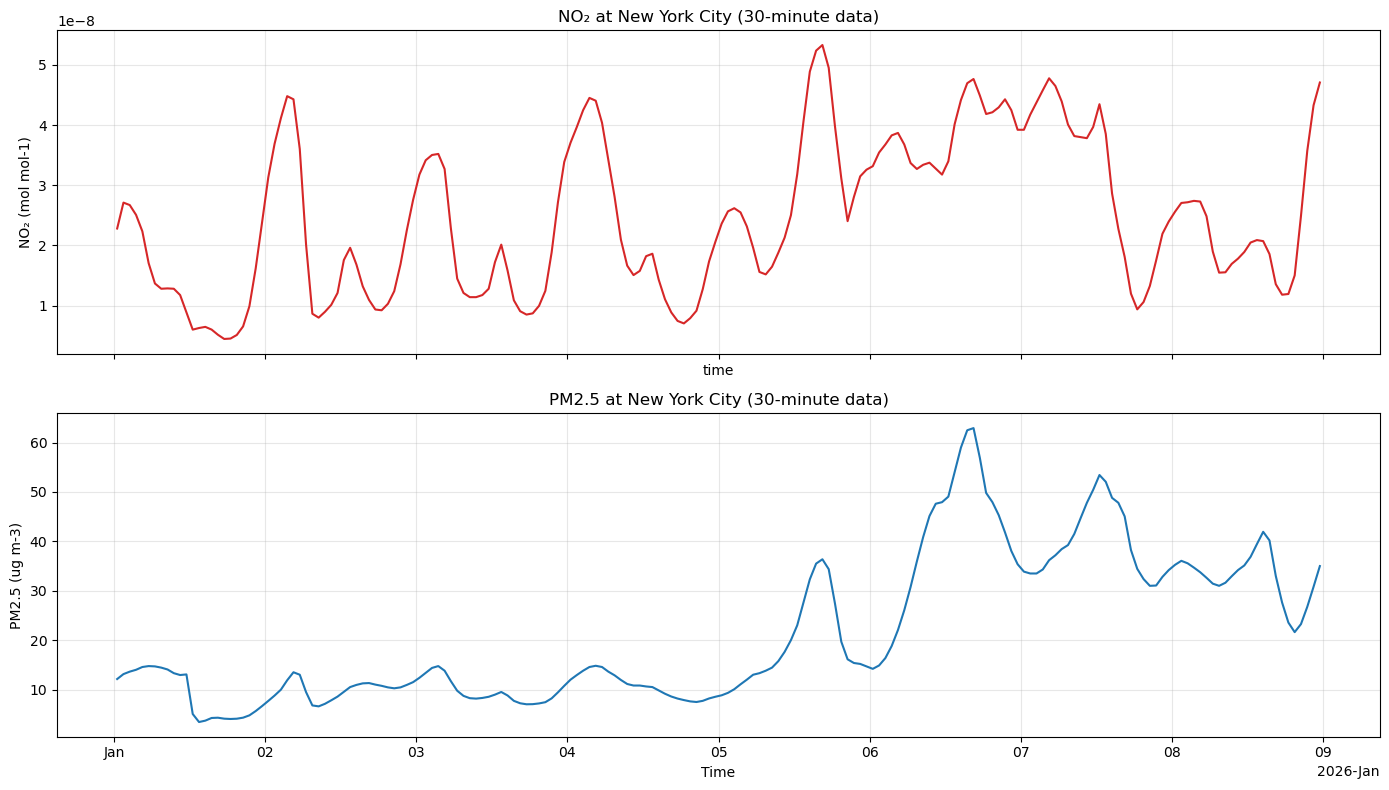

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

no2_ts.plot(ax=axes[0], color="tab:red")
axes[0].set_title("NO₂ at New York City (30-minute data)")
axes[0].set_ylabel(f"NO₂ ({no2_ts.attrs.get('units', 'unknown units')})")
axes[0].grid(True, alpha=0.3)

pm25_ts.plot(ax=axes[1], color="tab:blue")
axes[1].set_title("PM2.5 at New York City (30-minute data)")
axes[1].set_ylabel(f"PM2.5 ({pm25_ts.attrs.get('units', 'unknown units')})")
axes[1].set_xlabel("Time")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

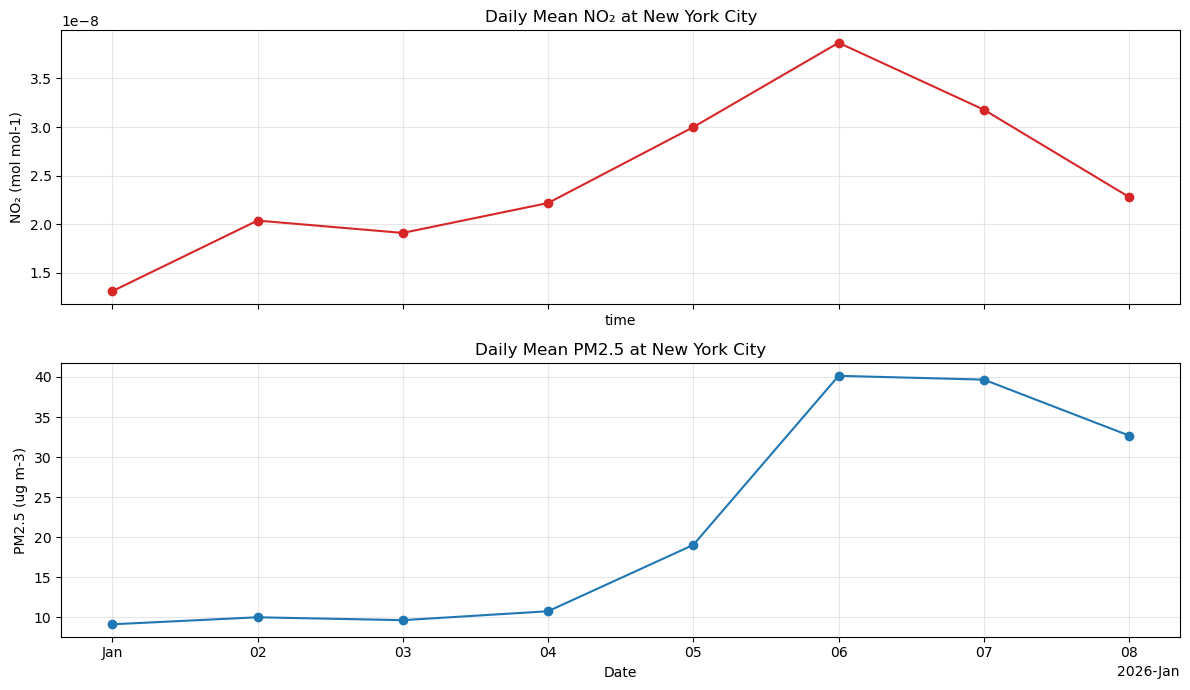

In [12]:
no2_daily = no2_ts.resample(time="1D").mean()
pm25_daily = pm25_ts.resample(time="1D").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

no2_daily.plot(marker="o", ax=axes[0], color="tab:red")
axes[0].set_title("Daily Mean NO₂ at New York City")
axes[0].set_ylabel(f"NO₂ ({no2_daily.attrs.get('units', 'unknown units')})")
axes[0].grid(True, alpha=0.3)

pm25_daily.plot(marker="o", ax=axes[1], color="tab:blue")
axes[1].set_title("Daily Mean PM2.5 at New York City")
axes[1].set_ylabel(f"PM2.5 ({pm25_daily.attrs.get('units', 'unknown units')})")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
df = pd.DataFrame({
    "time": no2_ts["time"].values,
    "NO2": no2_ts.values,
    "PM25": pm25_ts.values
}).set_index("time")

display(df.head())

,NO2,PM25
time,,
2026-01-01 00:30:00,2.281740e-08,12.1250
2026-01-01 01:30:00,2.712477e-08,13.1250
2026-01-01 02:30:00,2.671732e-08,13.6250
2026-01-01 03:30:00,2.508750e-08,14.0000
2026-01-01 04:30:00,2.235174e-08,14.5625


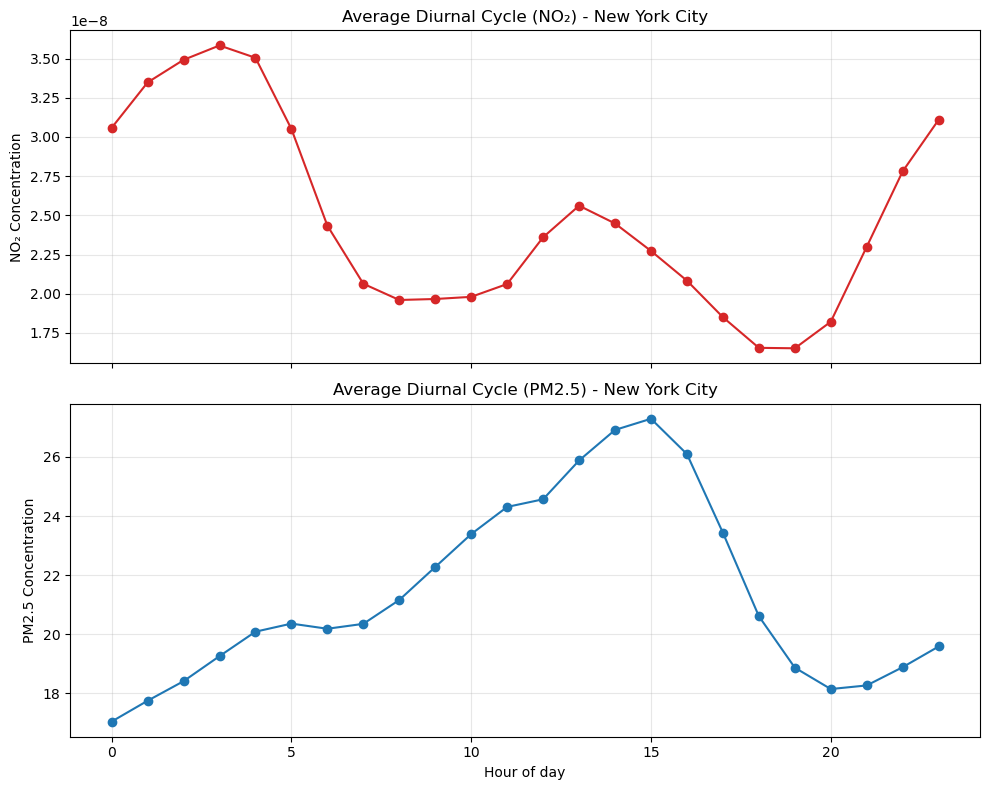

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

diurnal_mean = df.groupby(df.index.hour).mean()

# NO2
axes[0].plot(diurnal_mean.index, diurnal_mean["NO2"], marker="o", color="tab:red")
axes[0].set_title("Average Diurnal Cycle (NO₂) - New York City")
axes[0].set_ylabel("NO₂ Concentration")
axes[0].grid(True, alpha=0.3)

# PM2.5
axes[1].plot(diurnal_mean.index, diurnal_mean["PM25"], marker="o", color="tab:blue")
axes[1].set_title("Average Diurnal Cycle (PM2.5) - New York City")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("PM2.5 Concentration")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
lat_min, lat_max = 39.5, 41.5
lon_min, lon_max = -75.5, -72.5

region_ds = week_ds.sel(
    lat=slice(lat_min, lat_max),
    lon=slice(lon_min, lon_max)
).isel(lev=0)

In [16]:
sample_time = str(region_ds.time.values[0])
print("Sample time:", sample_time)

no2_map = region_ds["NO2"].isel(time=0).compute()
pm25_map = region_ds["PM25_RH35"].isel(time=0).compute()

Sample time: 2026-01-01T00:30:00.000000000


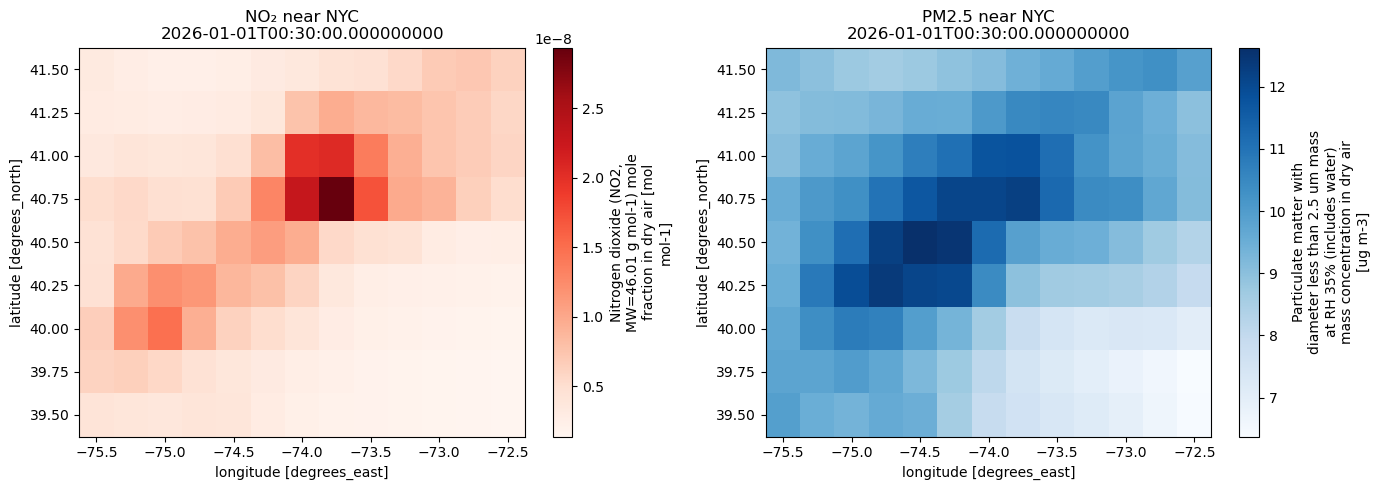

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no2_map.plot(ax=axes[0], cmap="Reds")
axes[0].set_title(f"NO₂ near NYC\n{sample_time}")

pm25_map.plot(ax=axes[1], cmap="Blues")
axes[1].set_title(f"PM2.5 near NYC\n{sample_time}")

plt.tight_layout()
plt.show()

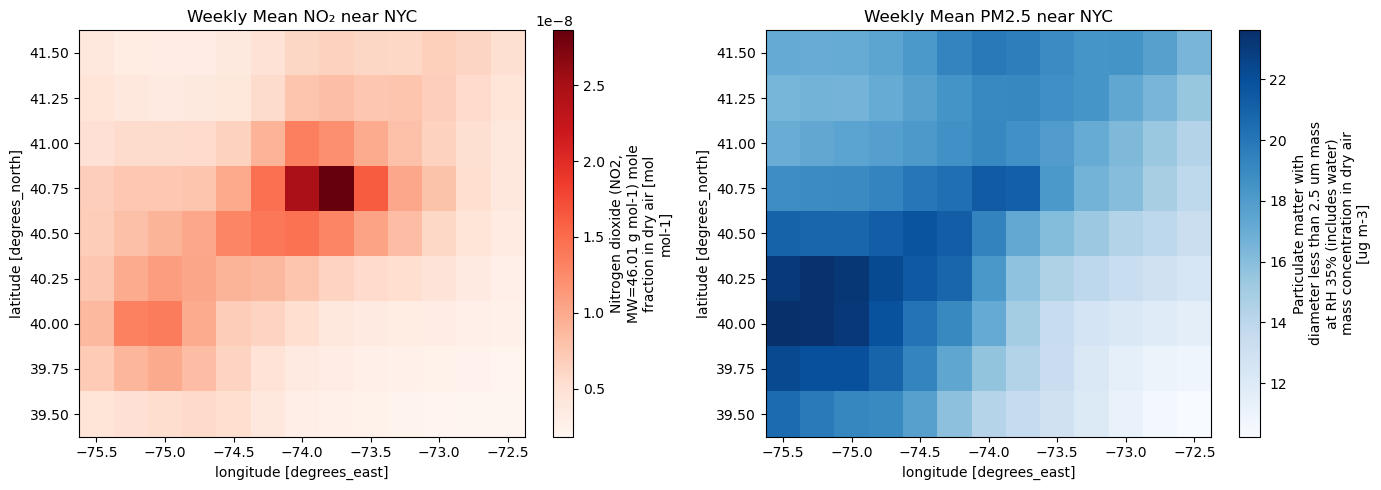

In [18]:
no2_week_mean = region_ds["NO2"].mean(dim="time").compute()
pm25_week_mean = region_ds["PM25_RH35"].mean(dim="time").compute()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no2_week_mean.plot(ax=axes[0], cmap="Reds")
axes[0].set_title("Weekly Mean NO₂ near NYC")

pm25_week_mean.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Weekly Mean PM2.5 near NYC")

plt.tight_layout()
plt.show()

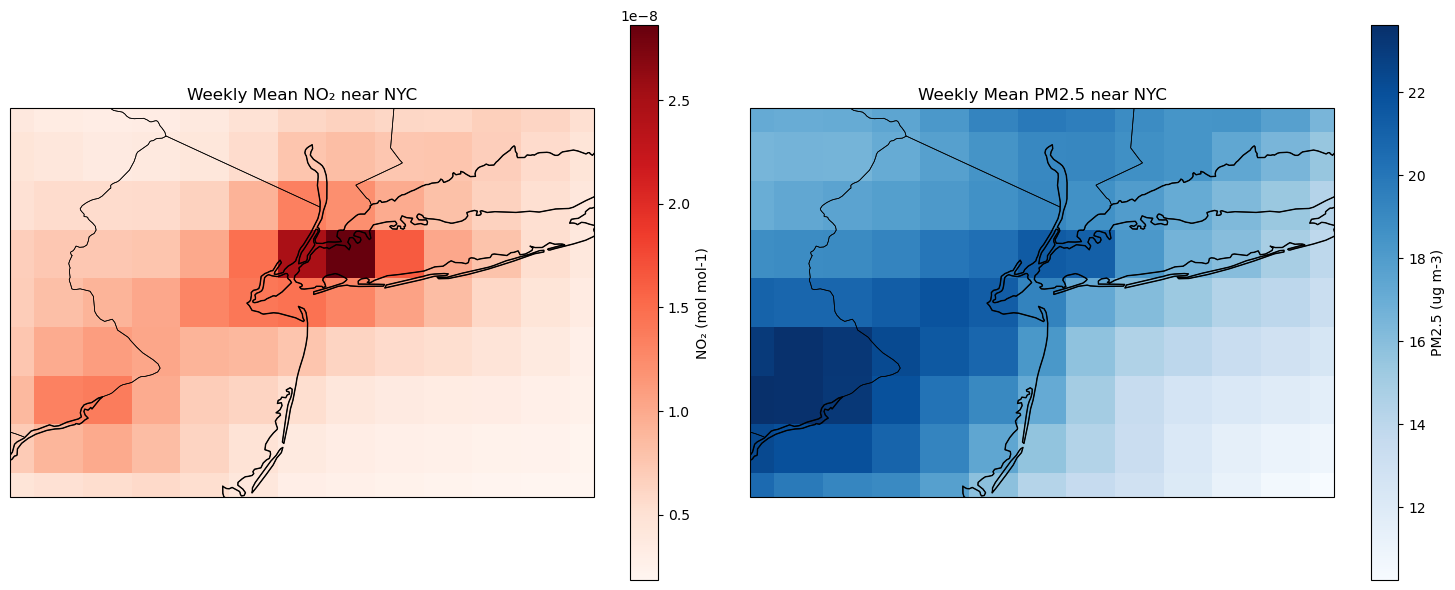

In [19]:
fig, axes = plt.subplots(
    1, 2, figsize=(15, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax in axes:
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    ax.add_feature(cfeature.STATES, linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

no2_week_mean.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    cbar_kwargs={"label": f"NO₂ ({no2_week_mean.attrs.get('units', 'unknown units')})"}
)
axes[0].set_title("Weekly Mean NO₂ near NYC")

pm25_week_mean.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    cbar_kwargs={"label": f"PM2.5 ({pm25_week_mean.attrs.get('units', 'unknown units')})"}
)
axes[1].set_title("Weekly Mean PM2.5 near NYC")

plt.tight_layout()
plt.show()